In [1]:
import colorcet as cc
import gstools as gs
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from context_flux_no.simulations.pde.euler import Euler2D
from context_flux_no.simulations.utils import generate_dataset
from context_flux_no.waveforms.grf import GaussianRandomField2D


2026-08-25 16:27:01,363 INFO CLAW: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


W0825 16:27:02.732796  941158 gpu_helpers.cc:80] Unable to enable peer access between GPUs 0 and 9; status: INTERNAL: failed to enable peer access from 0x14f598e9f1c0 to 0x14f5acc053f0: INTERNAL: CUDA error: : CUDA_ERROR_TOO_MANY_PEERS: peer mapping resources exhausted
W0825 16:27:02.751581  941158 gpu_helpers.cc:80] Unable to enable peer access between GPUs 1 and 9; status: INTERNAL: failed to enable peer access from 0x14f5a4c02b20 to 0x14f5acc053f0: INTERNAL: CUDA error: : CUDA_ERROR_TOO_MANY_PEERS: peer mapping resources exhausted
W0825 16:27:02.768629  941158 gpu_helpers.cc:80] Unable to enable peer access between GPUs 2 and 9; status: INTERNAL: failed to enable peer access from 0x14f59cc03060 to 0x14f5acc053f0: INTERNAL: CUDA error: : CUDA_ERROR_TOO_MANY_PEERS: peer mapping resources exhausted
W0825 16:27:02.782173  941158 gpu_helpers.cc:80] Unable to enable peer access between GPUs 3 and 9; status: INTERNAL: failed to enable peer access from 0x14f594c03b60 to 0x14f5acc053f0: INTE

In [2]:
x, y = jnp.linspace(0, 1, 64), jnp.linspace(0, 1, 64)
grf = GaussianRandomField2D(gs.Gaussian(dim=2, var=1, len_scale=0.3))
u0 = grf.sample((x, y), jax.random.key(0))

In [3]:
from collections.abc import Callable, Sequence
from typing import ClassVar, Literal

import equinox as eqx
import numpy as np
from clawpack import pyclaw
from clawpack import riemann
from context_flux_no.simulations.pde.base import AbstractHyperbolicConservationLaw
from context_flux_no.simulations.pdesolve import pdesolve_pyclaw
from jaxtyping import Float


class Euler2DClawpack(AbstractHyperbolicConservationLaw):
    n_spatial_dims: ClassVar[int] = 2
    field_rank_names: ClassVar[tuple[tuple[int, str]]] = (
        (0, "rho"),
        (1, "m"),
        (0, "E"),
    )

    gamma: float = eqx.field(static=True)

    def __init__(self, gamma: float = 1.4):
        self.gamma = gamma

    @property
    def parameters(self) -> dict[str, float]:
        return {"gamma": self.gamma}

    def solve(
        self,
        ic_factory: Callable[[Float[np.ndarray, " Nx"]], Float[np.ndarray, " Nx"]],
        x_spans: Sequence[tuple[float, float]],
        Nxs: Sequence[int],
        t_span: tuple[float, float],
        Nt: int,
        bc: Literal["periodic"],  # TODO: extend to other types as well
        **pdesolve_kwargs,
    ) -> tuple[
        Float[np.ndarray, "time dim x_grid"],
        Float[np.ndarray, " time"],
        list[Float[np.ndarray, " ?x"]],
    ]:
        # Setting from https://www.clawpack.org/gallery/pyclaw/gallery/quadrants.html
        solver = pyclaw.ClawSolver2D(riemann.euler_4wave_2D)
        solver.transverse_waves = 2

        solver.num_eqn = self.n_eqns

        problem_data = self.parameters
        u, t, x_grid = pdesolve_pyclaw(
            solver,
            problem_data,
            ic_factory,
            x_spans,
            Nxs,
            t_span,
            Nt,
            bc,
            **pdesolve_kwargs,
        )
        return u, t, x_grid

In [4]:
keys = jax.random.split(jax.random.key(1), 4)

euler = Euler2D(gamma=1.4)
key = jax.random.key(1)


grf = GaussianRandomField2D(gs.Gaussian(dim=2, var=1.0, len_scale=0.3))


def initial_condition(xs, key=jax.random.key(0)):
    rho_key, ux_key, uy_key, energy_key = jax.random.split(key, 4)

    rho_field = jnp.asarray(grf.sample(xs, rho_key))
    ux_field = jnp.asarray(grf.sample(xs, ux_key))
    uy_field = jnp.asarray(grf.sample(xs, uy_key))
    energy_field = jnp.asarray(grf.sample(xs, energy_key))

    # 밀도는 항상 양수
    rho = 1.0 + 0.1 * jnp.tanh(rho_field)

    velocity_x = 0.05 * jnp.tanh(ux_field)
    velocity_y = 0.05 * jnp.tanh(uy_field)

    momentum_x = rho * velocity_x
    momentum_y = rho * velocity_y

    # 내부에너지 밀도를 항상 양수로 설정
    internal_energy = 2.5 + 0.25 * jnp.tanh(energy_field)

    kinetic_energy = 0.5 * rho * (velocity_x**2 + velocity_y**2)
    total_energy = internal_energy + kinetic_energy

    # (rho, rho*u, rho*v, E)
    return jnp.stack(
        (
            rho,
            momentum_x,
            momentum_y,
            total_energy,
        ),
        axis=0,
    )

In [5]:
sol = euler.solve(
    initial_condition,
    ((0.0, 1.0), (0.0, 1.0)),
    (64, 64),
    (0.0, 0.5),
    100,
)

In [6]:
sol

<xarray.Dataset> Size: 7MB
Dimensions:  (ic: 1, t: 101, dim: 4, x: 64, y: 64, param: 1)
Coordinates:
  * t        (t) float32 404B 0.0 0.005 0.01 0.015 0.02 ... 0.485 0.49 0.495 0.5
  * dim      (dim) <U3 48B 'u_0' 'u_1' 'u_2' 'u_3'
  * x        (x) float32 256B 0.007812 0.02344 0.03906 ... 0.9609 0.9766 0.9922
  * y        (y) float32 256B 0.007812 0.02344 0.03906 ... 0.9609 0.9766 0.9922
  * param    (param) <U5 20B 'gamma'
Dimensions without coordinates: ic
Data variables:
    values   (ic, t, dim, x, y) float32 7MB 0.9544 0.9542 0.9539 ... 2.843 2.84
    coeffs   (param) float64 8B 1.4

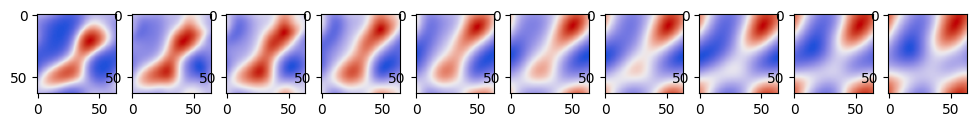

In [7]:
fig, axes = plt.subplots(1, 10, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(sol["values"][0, i * 10, 0], cmap=cc.cm.coolwarm)

In [8]:
euler_claw = Euler2DClawpack(gamma=1.4)
sol_claw = euler_claw.solve(initial_condition,
    ((0.0, 1.0), (0.0, 1.0)),
    (64, 64),
    (0.0, 0.5),
    100,"periodic")

[<clawpack.pyclaw.geometry.Dimension object at 0x14f75c185b80>, <clawpack.pyclaw.geometry.Dimension object at 0x14f8241a8d10>]
2026-08-25 16:31:54,112 INFO CLAW: Solution 0 computed for time t=0.000000
2026-08-25 16:31:54,114 INFO CLAW: Solution 1 computed for time t=0.005000
2026-08-25 16:31:54,117 INFO CLAW: Solution 2 computed for time t=0.010000
2026-08-25 16:31:54,119 INFO CLAW: Solution 3 computed for time t=0.015000
2026-08-25 16:31:54,121 INFO CLAW: Solution 4 computed for time t=0.020000
2026-08-25 16:31:54,124 INFO CLAW: Solution 5 computed for time t=0.025000
2026-08-25 16:31:54,126 INFO CLAW: Solution 6 computed for time t=0.030000
2026-08-25 16:31:54,128 INFO CLAW: Solution 7 computed for time t=0.035000
2026-08-25 16:31:54,130 INFO CLAW: Solution 8 computed for time t=0.040000
2026-08-25 16:31:54,132 INFO CLAW: Solution 9 computed for time t=0.045000
2026-08-25 16:31:54,134 INFO CLAW: Solution 10 computed for time t=0.050000
2026-08-25 16:31:54,136 INFO CLAW: Solution 11 

In [10]:
sol_claw[0].shape

(101, 4, 64, 64)

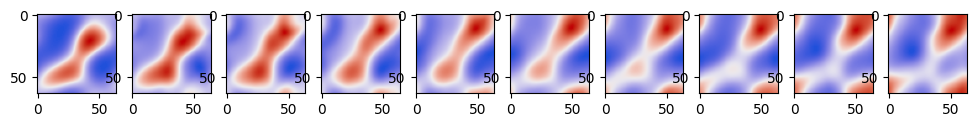

In [12]:
fig, axes = plt.subplots(1, 10, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(sol_claw[0][i * 10, 0], cmap=cc.cm.coolwarm)

In [ ]:
dataset = generate_dataset(
    n_coeffs=50,
    n_ics_per_coeff=500,
    pde_factory=Euler2D,
    initial_condition_fn=initial_condition,
    coeff_range_dict={"gamma": (1.2, 5 / 3)},
    x_span=((0, 1), (0, 1)),
    Nx=(50, 50),
    t_span=(0, 0.5),
    Nt=100,
    seed=0,
)


  0%|                                                                                                                                                                     | 0/50 [00:00<?, ?it/s]

In [8]:
dataset["values"].nbytes / 1e9

0.101

In [1]:
dataset["values"].shape


NameError: name 'dataset' is not defined

In [ ]:
from pathlib import Path

savedir = Path("../../data/")
savedir.mkdir(parents=True, exist_ok=True)
dataset.to_netcdf(savedir / "2d_euler_training_50_500.hdf5")

.venv/bin/python ./scripts/training/train_multiphysics_2d.py \
  data=2d_scalar \
  model=hyperfluxno_2d_scalar_global \
  training.context_length=10 \
  training.batch_size=32 \
  training.optimizer.learning_rate.warmup_steps=10000 \
  training.optimizer.learning_rate.decay_steps=40000 \
  hydra.launcher.partition=h100 \
  hydra.launcher.cpus_per_task=12 \
  hydra.launcher.mem_gb=350 \
  model.key.seed=10 \
  --multirun